## PROJECT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [ ]:
a=pd.read_csv(r"Fraud.csv")

In [ ]:
m=pd.DataFrame(a)

In [ ]:
m.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
m.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
196374,13,CASH_OUT,37922.70,C583204682,49753.00,11830.30,C1099983005,226453.68,264376.38,0.0,0.0
1024847,48,PAYMENT,12338.69,C1511028058,86208.59,73869.90,M1132332349,0.00,0.00,0.0,0.0
131824,11,TRANSFER,1833611.48,C428470148,94288.00,0.00,C721233394,246535.59,1698885.51,0.0,0.0
410015,18,PAYMENT,26314.71,C918379898,16948.82,0.00,M1341023157,0.00,0.00,0.0,0.0
1712,1,CASH_IN,19872.97,C269458366,3561106.22,3580979.18,C832279283,168814.13,185389.80,0.0,0.0


In [ ]:
m.tail(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1604006,156,PAYMENT,7805.08,C1167913144,224030.0,216224.92,M637507319,0.00,0.00,0.0,0.0
1604007,156,CASH_OUT,35315.92,C785852424,6098.0,0.00,C169764695,4508414.25,4543730.17,0.0,0.0
1604008,156,CASH_OUT,816670.66,C1356051936,255794.0,0.00,C1797331500,11725.34,828396.00,0.0,0.0
1604009,156,PAYMENT,3634.77,C1919456882,8289.0,4654.23,M737799910,0.00,0.00,0.0,0.0
1604010,156,PAYMENT,12323.00,C1022956793,2.0,NaN,NaN,NaN,NaN,NaN,NaN


1] The feature HEAD,SAMPLE,TAIL showing three types of values NUMERICAL(amount,oldbalanceOrg,oldbalanceDest,oldbalanceDest),CATEGORICAL(type) and BINARY (Is fraud,isFlaggedFraud)
2] Head(5) showing top 5 rows of dataset
3]Sample(5) showing any 5 random rows of dataset
4]Tail(5) showing the bottom 5 rows of dataset

In [ ]:
m.shape

(1604011, 11)

Total of 1604011 rows and 11 columns are present in the dataset

In [ ]:
m.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

there are missing value in columns (newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud)

In [ ]:
m=m.dropna()

After applying dropna(). rows with missing values were removed.

In [ ]:
m.dtypes

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud           float64
isFlaggedFraud    float64
dtype: object

After checking dtypes as we can see there are two columns with dtype object which needs to be converted

In [ ]:
m.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

with the help of columns we can observe some of the columns are not necessary for building model

In [ ]:
m.drop("step",axis=1,inplace=True)

In [ ]:
m.drop("nameOrig",axis=1,inplace=True)

In [ ]:
m.drop("nameDest",axis=1,inplace=True)

With the help of drop function we have dropped columns which are not necessary

In [ ]:
m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1604010 entries, 0 to 1604009
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   type            1604010 non-null  object 
 1   amount          1604010 non-null  float64
 2   oldbalanceOrg   1604010 non-null  float64
 3   newbalanceOrig  1604010 non-null  float64
 4   oldbalanceDest  1604010 non-null  float64
 5   newbalanceDest  1604010 non-null  float64
 6   isFraud         1604010 non-null  float64
 7   isFlaggedFraud  1604010 non-null  float64
dtypes: float64(7), object(1)
memory usage: 110.1+ MB


As we can see there is still one column who's dtype is object so we need to convert into numerical

In [ ]:
le=LabelEncoder()

In [ ]:
m["type"]=le.fit_transform(m["type"])

With the help of label encoder we have converted the column into numerical

In [ ]:
m.describe()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.604010e+06,1.604010e+06,1.604010e+06,1.604010e+06,1.604010e+06,1.604010e+06,1.604010e+06,1604010.0
mean,1.707983e+00,1.620470e+05,8.620570e+05,8.829904e+05,9.906276e+05,1.115334e+06,1.102238e-03,0.0
std,1.347116e+00,2.707680e+05,2.934862e+06,2.971194e+06,2.303831e+06,2.406570e+06,3.318167e-02,0.0
min,0.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.000000e+00,1.299894e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,1.000000e+00,7.806103e+04,1.523400e+04,0.000000e+00,1.328866e+05,2.242344e+05,0.000000e+00,0.0
75%,3.000000e+00,2.172913e+05,1.243753e+05,1.658709e+05,9.385969e+05,1.153917e+06,0.000000e+00,0.0
max,4.000000e+00,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In most of the columns the mean is greater then median but As we can see there is negative skewness present in columns like "amount",newbalanceDest

In [ ]:
m.skew()

type               0.206809
amount             6.286950
oldbalanceOrg      5.115762
newbalanceOrig     5.050797
oldbalanceDest     5.355642
newbalanceDest     5.030793
isFraud           30.070721
isFlaggedFraud     0.000000
dtype: float64

In [ ]:
m["amount"]=np.log1p(m["amount"])

In [ ]:
m["oldbalanceOrg"]=np.log1p(m["oldbalanceOrg"])

In [ ]:
m["newbalanceOrig"]=np.log1p(m["newbalanceOrig"])

In [ ]:
m["oldbalanceDest"]=np.log1p(m["oldbalanceDest"])

In [ ]:
m["newbalanceDest"]=np.log1p(m["newbalanceDest"])

In [ ]:
m.skew()

type               0.206809
amount            -0.600634
oldbalanceOrg     -0.272481
newbalanceOrig     0.408484
oldbalanceDest    -0.235843
newbalanceDest    -0.384730
isFraud           30.070721
isFlaggedFraud     0.000000
dtype: float64

with the help of nplog1p we have dealth with negative skewness

In [ ]:
m

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,3,9.194276,12.044359,11.984786,0.000000,0.000000,0.0,0.0
1,3,7.531166,9.964112,9.872292,0.000000,0.000000,0.0,0.0
2,4,5.204007,5.204007,0.000000,0.000000,0.000000,1.0,0.0
3,1,5.204007,5.204007,0.000000,9.960954,0.000000,1.0,0.0
4,3,9.364703,10.634773,10.305174,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...
1604005,0,12.599072,8.428362,12.614392,14.682137,14.549123,0.0,0.0
1604006,3,8.962658,12.319540,12.284079,0.000000,0.000000,0.0,0.0
1604007,1,10.472117,8.715880,0.000000,15.321456,15.329259,0.0,0.0
1604008,1,13.612992,12.452132,0.000000,9.369593,13.627248,0.0,0.0


In [ ]:
m.isnull().sum()

type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

type                  Axes(0.125,0.77;0.110714x0.11)
amount             Axes(0.257857,0.77;0.110714x0.11)
oldbalanceOrg      Axes(0.390714,0.77;0.110714x0.11)
newbalanceOrig     Axes(0.523571,0.77;0.110714x0.11)
oldbalanceDest     Axes(0.656429,0.77;0.110714x0.11)
newbalanceDest     Axes(0.789286,0.77;0.110714x0.11)
isFraud              Axes(0.125,0.638;0.110714x0.11)
isFlaggedFraud    Axes(0.257857,0.638;0.110714x0.11)
dtype: object

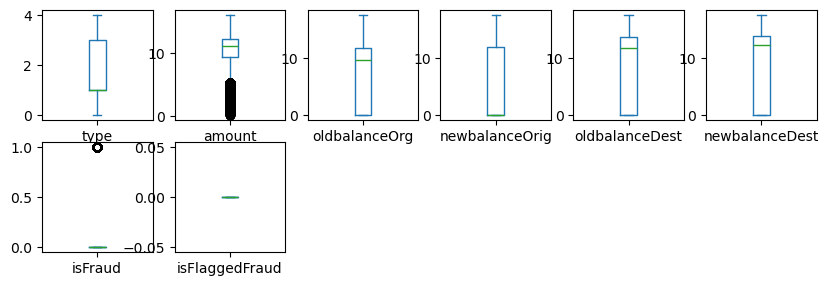

In [ ]:
m.plot(kind="box",subplots=True,layout=(6,6),figsize=(10,10))

In [ ]:
from scipy.stats import zscore

In [ ]:
m.shape

(1604010, 8)

In [ ]:
z=np.abs(zscore(m))
df=m[(z < 3).all(axis=1)]

With the help of zscore technique we have dealt with outliers

In [ ]:
df.shape

(1596194, 8)

type                  Axes(0.125,0.77;0.110714x0.11)
amount             Axes(0.257857,0.77;0.110714x0.11)
oldbalanceOrg      Axes(0.390714,0.77;0.110714x0.11)
newbalanceOrig     Axes(0.523571,0.77;0.110714x0.11)
oldbalanceDest     Axes(0.656429,0.77;0.110714x0.11)
newbalanceDest     Axes(0.789286,0.77;0.110714x0.11)
isFraud              Axes(0.125,0.638;0.110714x0.11)
isFlaggedFraud    Axes(0.257857,0.638;0.110714x0.11)
dtype: object

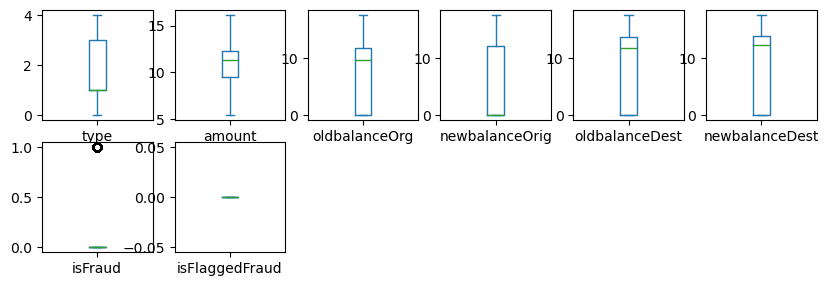

In [ ]:
df.plot(kind="box",subplots=True,layout=(6,6),figsize=(10,10))

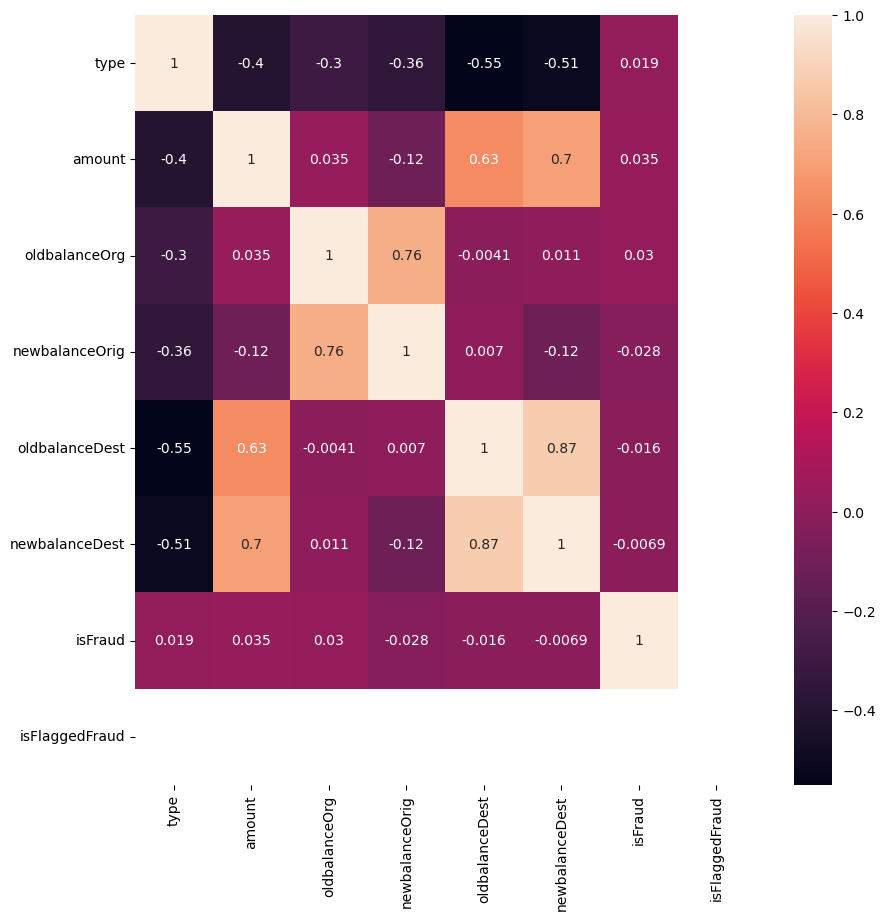

In [ ]:
sns.heatmap(df.corr(),figsize=(10,10),annot=True)

there is strong corelation with newbalanceDest and less corelation with oldbalanceDest also isFlaggedFraud is not contributing anything so we will get rid of it

In [ ]:
df.drop("isFlaggedFraud",axis=1,inplace=True)

In [ ]:
df.columns

Index(['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud'],
      dtype='object')

In [ ]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [ ]:
sm=SMOTE()

In [ ]:
xtrain,ytrain=sm.fit_resample(x,y)

In [ ]:
ytrain.value_counts()

isFraud
0.0    1594436
1.0    1594436
Name: count, dtype: int64

<Axes: xlabel='isFraud', ylabel='count'>

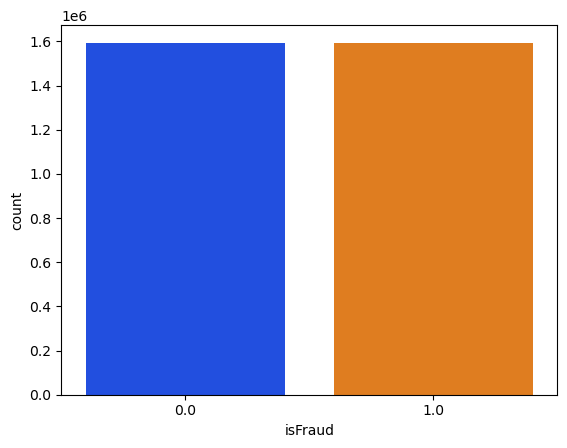

In [ ]:
ytrain.shape
sb.countplot(x=ytrain,palette="bright")

with the help of smote technique we have dealt with imbalance data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(xtrain,ytrain,test_size=.30,random_state=42)

In [ ]:
rf=RandomForestClassifier(n_estimators=400,random_state=42)

In [ ]:
ad=AdaBoostClassifier()

In [ ]:
h=[rf,ad]

In [ ]:
for i in h:
    i.fit(x_train,y_train)
    prep=i.predict(x_test)
    print("the scors for", i,"is")
    print("the accuracy score for",i,"is",accuracy_score(y_test,prep))
    print("the confusion_matrix for",i,"is",confusion_matrix(y_test,prep))
    print("the classification_report for",i,"is",classification_report(y_test,prep))

the scors for RandomForestClassifier(n_estimators=400, random_state=42) is
the accuracy score for RandomForestClassifier(n_estimators=400, random_state=42) is 0.9988595763184908
the confusion_matrix for RandomForestClassifier(n_estimators=400, random_state=42) is [[477341    682]
 [   409 478230]]
the classification_report for RandomForestClassifier(n_estimators=400, random_state=42) is               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    478023
         1.0       1.00      1.00      1.00    478639

    accuracy                           1.00    956662
   macro avg       1.00      1.00      1.00    956662
weighted avg       1.00      1.00      1.00    956662

the scors for AdaBoostClassifier() is
the accuracy score for AdaBoostClassifier() is 0.9592489301341539
the confusion_matrix for AdaBoostClassifier() is [[451215  26808]
 [ 12177 466462]]
the classification_report for AdaBoostClassifier() is               precision    recall  f1-sco

In [ ]:
def fraudd(f):
    f=f.reshape(1,-1)
    pro=i.predict(f)
    print("the score of ",pro)
    if pro == 0:
        print("its not a fraud transaction")
    else:
        print("its a fraud transaction")

In [ ]:
f=np.array([3,9.194276,12.044359,11.984786,0.000000,0.000000])

In [ ]:
fraudd(f)

the score of  [0.]
its not a fraud transaction


In [ ]:
m.head(5)

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,3,9.194276,12.044359,11.984786,0.0,0.0,0.0
1,3,7.531166,9.964112,9.872292,0.0,0.0,0.0
4,3,9.364703,10.634773,10.305174,0.0,0.0,0.0
5,3,8.964275,10.894162,10.737337,0.0,0.0,0.0
6,3,8.869085,12.118312,12.078740,0.0,0.0,0.0


This project focused on building a machine learning model to detect fraudulent transactions in a financial dataset. The dataset contained features such as 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', and a target variable 'isFraud'. initially the shape of data was (1604011, 11) ,the datatype was int,object,float. there was null values presented so with help of function like dropna we removed the null values. we droped columns which was not contributing to model. with the help of preprocessing technique like label encoder we converted categorial data into numerical. There was skewness presented in the data which was dealt with the help of nplog1p technique. We detected the outliers with the help of Boxplot visualisation and was dealt the outlier with zscore technique. we saw corelation with help of Heatmap. The data was imabalanced so we applied SMOTE to deal with the imbalanced data. we sent the data into training and with the help of techniques like adaboost and randomforest classifer the model was trained and effectively identified patterns in transactional data to flag fraudulent behavior.